In [11]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor, Pool

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

In [12]:
# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path.cwd() / "notebook_exports"
ROUND_DATA_PATH = OUTPUT_DIR / "round_level_modeling_dataset_v1.parquet"

TEST_SIZE = 0.20
VALID_SIZE_WITHIN_TRAIN = 0.20
RANDOM_STATE = 42

USE_LAYOUT_ID = True
USE_DIVISION = True

DIVISION_ORDER = ["MA4", "MA3", "MA2", "MA1", "MPO"]
WIND_SPEED_ORDER = ["calm", "light", "moderate", "strong"]
WIND_GUST_ORDER = ["low", "mild", "high", "very_high"]

CATBOOST_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 20000,
    "depth": 6,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "random_seed": RANDOM_STATE,
    "verbose": 250,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "max_ctr_complexity": 1,
    "store_all_simple_ctr": False,
    "task_type": "CPU",
}

print("Using local round dataset:", ROUND_DATA_PATH)


Using local round dataset: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports\round_level_modeling_dataset_v1.parquet


In [13]:
# -----------------------------------------------------------------------------
# Load local round-level dataset
# -----------------------------------------------------------------------------

round_level_df = pd.read_parquet(ROUND_DATA_PATH)

print("Round-level shape:", round_level_df.shape)
round_level_df.head()


Round-level shape: (419842, 28)


,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating
0,2025,90004,1,PDGA#240866,248066,731340,MA4,777.0,60.0,18,4262.0,236.777778,54.0,3.000000,2.99,2.99,5.3,5.3,15.6,0.0,0.0,1018.5,82.0,6.0,78.925926,12743.38,22588.6,2323.23
1,2025,90022,1,PDGA#139372,303386,708703,MPO,944.0,65.0,22,6640.0,301.818182,69.0,3.136364,0.69,0.69,3.0,3.0,3.7,0.0,0.0,1009.0,83.0,-4.0,96.231884,4581.60,19920.0,651.36
2,2025,90022,1,PDGA#178707,303386,708703,FPO,921.0,67.0,22,6640.0,301.818182,69.0,3.136364,1.38,1.38,2.7,2.7,1.1,0.0,0.0,1009.0,91.0,-2.0,96.231884,9163.20,17928.0,1270.98
3,2025,90022,1,PDGA#235527,303386,708703,MA2,861.0,72.0,22,6640.0,301.818182,69.0,3.136364,1.25,1.25,2.3,2.3,2.2,0.0,0.0,1009.7,89.0,3.0,96.231884,8300.00,15272.0,1076.25
4,2025,90022,2,PDGA#208891,303386,708709,MA50,887.0,79.0,22,7337.0,333.500000,70.0,3.181818,1.71,1.71,4.2,4.2,5.5,0.0,0.0,1004.7,77.0,9.0,104.814286,12546.27,30815.4,1516.77


In [14]:
# -----------------------------------------------------------------------------
# Validate required columns
# -----------------------------------------------------------------------------

required_cols = [
    "event_year",
    "tourn_id",
    "round_number",
    "player_key",
    "course_id",
    "layout_id",
    "division",
    "player_rating",
    "actual_round_strokes",
    "round_strokes_over_par",
    "hole_count",
    "round_total_hole_length",
    "round_avg_hole_length",
    "round_total_par",
    "round_avg_hole_par",
    "round_wind_speed_mps_mean",
    "round_wind_speed_mps_max",
    "round_wind_gust_mps_mean",
    "round_wind_gust_mps_max",
    "round_temp_c_mean",
    "round_precip_mm_sum",
    "round_precip_mm_mean",
    "round_pressure_hpa_mean",
    "round_humidity_pct_mean",
    "round_length_over_par",
    "wind_x_round_length",
    "gust_x_round_length",
    "wind_x_player_rating",
]

missing = [c for c in required_cols if c not in round_level_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("All required columns present.")


All required columns present.


In [15]:
# -----------------------------------------------------------------------------
# Wind bucket helpers
# -----------------------------------------------------------------------------

def wind_speed_bucket(speed: float | None) -> str:
    if pd.isna(speed):
        return "unknown"
    if speed < 2.0:
        return "calm"
    if speed < 5.0:
        return "light"
    if speed < 8.0:
        return "moderate"
    if speed < 12.0:
        return "strong"
    return "very_strong"


def wind_gust_bucket(speed: float | None) -> str:
    if pd.isna(speed):
        return "unknown"
    if speed < 3.0:
        return "low"
    if speed < 6.0:
        return "mild"
    if speed < 10.0:
        return "high"
    return "very_high"


In [16]:
# -----------------------------------------------------------------------------
# Cleanup and feature prep
# -----------------------------------------------------------------------------

model_df = round_level_df.copy()

if "round_wind_speed_bucket" not in model_df.columns:
    model_df["round_wind_speed_bucket"] = model_df["round_wind_speed_mps_mean"].apply(wind_speed_bucket)

if "round_wind_gust_bucket" not in model_df.columns:
    model_df["round_wind_gust_bucket"] = model_df["round_wind_gust_mps_mean"].apply(wind_gust_bucket)

model_df = model_df.dropna(
    subset=[
        "actual_round_strokes",
        "player_rating",
        "course_id",
        "round_total_hole_length",
        "round_total_par",
        "round_wind_speed_mps_mean",
        "round_wind_gust_mps_mean",
        "round_temp_c_mean",
        "round_precip_mm_mean",
    ]
).copy()

model_df["course_id"] = model_df["course_id"].astype("string")
model_df["layout_id"] = model_df["layout_id"].astype("string")
model_df["division"] = model_df["division"].astype("string")
model_df["round_wind_speed_bucket"] = model_df["round_wind_speed_bucket"].astype("string")
model_df["round_wind_gust_bucket"] = model_df["round_wind_gust_bucket"].astype("string")

print("Model dataframe shape:", model_df.shape)


Model dataframe shape: (419842, 30)


In [17]:
# -----------------------------------------------------------------------------
# Train / validation / test split
# -----------------------------------------------------------------------------

train_full_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df, valid_df = train_test_split(
    train_full_df,
    test_size=VALID_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_STATE,
)

print("Train rows:", len(train_df))
print("Valid rows:", len(valid_df))
print("Test rows: ", len(test_df))


Train rows: 268698
Valid rows: 67175
Test rows:  83969


In [18]:
# -----------------------------------------------------------------------------
# Shared helpers
# -----------------------------------------------------------------------------

def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def prepare_catboost_frame(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    test_df: pd.DataFrame,
    numeric_features: list[str],
    categorical_features: list[str],
    target_col: str,
):
    train_prepped = train_df.copy()
    valid_prepped = valid_df.copy()
    test_prepped = test_df.copy()

    for col in numeric_features + [target_col]:
        train_prepped[col] = pd.to_numeric(train_prepped[col], errors="coerce")
        valid_prepped[col] = pd.to_numeric(valid_prepped[col], errors="coerce")
        test_prepped[col] = pd.to_numeric(test_prepped[col], errors="coerce")

    train_prepped = train_prepped.dropna(subset=numeric_features + [target_col]).copy()
    valid_prepped = valid_prepped.dropna(subset=numeric_features + [target_col]).copy()
    test_prepped = test_prepped.dropna(subset=numeric_features + [target_col]).copy()

    for col in categorical_features:
        train_prepped[col] = train_prepped[col].astype("string").fillna("__MISSING__").astype(str)
        valid_prepped[col] = valid_prepped[col].astype("string").fillna("__MISSING__").astype(str)
        test_prepped[col] = test_prepped[col].astype("string").fillna("__MISSING__").astype(str)

        train_levels = set(train_prepped[col].unique())
        valid_prepped[col] = valid_prepped[col].where(valid_prepped[col].isin(train_levels), "__MISSING__")
        test_prepped[col] = test_prepped[col].where(test_prepped[col].isin(train_levels), "__MISSING__")

    feature_cols = numeric_features + categorical_features
    cat_idx = [feature_cols.index(c) for c in categorical_features]

    train_pool = Pool(train_prepped[feature_cols], label=train_prepped[target_col], cat_features=cat_idx)
    valid_pool = Pool(valid_prepped[feature_cols], label=valid_prepped[target_col], cat_features=cat_idx)
    test_pool = Pool(test_prepped[feature_cols], label=test_prepped[target_col], cat_features=cat_idx)

    return train_prepped, valid_prepped, test_prepped, train_pool, valid_pool, test_pool, feature_cols, cat_idx


In [19]:
# -----------------------------------------------------------------------------
# Stage 1: expected round strokes from non-weather features
# -----------------------------------------------------------------------------

stage1_numeric_features = [
    "player_rating",
    "round_number",
    "hole_count",
    "round_total_hole_length",
    "round_avg_hole_length",
    "round_total_par",
    "round_avg_hole_par",
    "round_length_over_par",
]

stage1_categorical_features = ["course_id"]

if USE_LAYOUT_ID and model_df["layout_id"].notna().any():
    stage1_categorical_features.append("layout_id")

if USE_DIVISION and model_df["division"].notna().any():
    stage1_categorical_features.append("division")

(
    stage1_train,
    stage1_valid,
    stage1_test,
    stage1_train_pool,
    stage1_valid_pool,
    stage1_test_pool,
    stage1_feature_cols,
    stage1_cat_idx,
) = prepare_catboost_frame(
    train_df=train_df,
    valid_df=valid_df,
    test_df=test_df,
    numeric_features=stage1_numeric_features,
    categorical_features=stage1_categorical_features,
    target_col="actual_round_strokes",
)

stage1_model = CatBoostRegressor(**CATBOOST_PARAMS)
stage1_model.fit(
    stage1_train_pool,
    eval_set=stage1_valid_pool,
    use_best_model=True,
    early_stopping_rounds=500,
)

stage1_train_pred = stage1_model.predict(stage1_train_pool)
stage1_valid_pred = stage1_model.predict(stage1_valid_pool)
stage1_test_pred = stage1_model.predict(stage1_test_pool)



0:	learn: 10.1693038	test: 10.0741583	best: 10.0741583 (0)	total: 81.1ms	remaining: 27m 1s
250:	learn: 4.4083595	test: 4.2815037	best: 4.2815037 (250)	total: 24.7s	remaining: 32m 25s
500:	learn: 4.2846651	test: 4.1647364	best: 4.1647364 (500)	total: 49.5s	remaining: 32m 7s
750:	learn: 4.2241223	test: 4.1112526	best: 4.1112526 (750)	total: 1m 14s	remaining: 31m 46s
1000:	learn: 4.1800746	test: 4.0745550	best: 4.0745550 (1000)	total: 1m 41s	remaining: 32m 9s
1250:	learn: 4.1452211	test: 4.0473387	best: 4.0473387 (1250)	total: 2m 22s	remaining: 35m 29s
1500:	learn: 4.1168593	test: 4.0254891	best: 4.0254891 (1500)	total: 2m 55s	remaining: 35m 59s
1750:	learn: 4.0910228	test: 4.0064927	best: 4.0064927 (1750)	total: 3m 21s	remaining: 35m 2s
2000:	learn: 4.0688924	test: 3.9914697	best: 3.9914697 (2000)	total: 3m 53s	remaining: 35m 4s
2250:	learn: 4.0479005	test: 3.9774021	best: 3.9774021 (2250)	total: 4m 26s	remaining: 34m 58s
2500:	learn: 4.0297262	test: 3.9652918	best: 3.9652918 (2500)	tota

In [20]:
# -----------------------------------------------------------------------------
# Stage 1 residuals
# -----------------------------------------------------------------------------

stage1_train["stage1_expected_round_strokes"] = stage1_train_pred
stage1_valid["stage1_expected_round_strokes"] = stage1_valid_pred
stage1_test["stage1_expected_round_strokes"] = stage1_test_pred

stage1_train["stage1_residual"] = stage1_train["actual_round_strokes"] - stage1_train["stage1_expected_round_strokes"]
stage1_valid["stage1_residual"] = stage1_valid["actual_round_strokes"] - stage1_valid["stage1_expected_round_strokes"]
stage1_test["stage1_residual"] = stage1_test["actual_round_strokes"] - stage1_test["stage1_expected_round_strokes"]

stage1_metrics_df = pd.DataFrame(
    [
        {
            "model": "stage1_expected_round_catboost",
            **regression_metrics(stage1_test["actual_round_strokes"], stage1_test["stage1_expected_round_strokes"]),
            "best_iteration": getattr(stage1_model, "best_iteration_", None),
        }
    ]
)

stage1_metrics_df


,model,mae,rmse,r2,best_iteration
0,stage1_expected_round_catboost,2.911426,3.844723,0.865078,19996


In [21]:
# -----------------------------------------------------------------------------
# Stage 2: residual from wind/weather features
# -----------------------------------------------------------------------------

stage2_numeric_features = [
    "round_wind_speed_mps_mean",
    "round_wind_speed_mps_max",
    "round_wind_gust_mps_mean",
    "round_wind_gust_mps_max",
    "round_temp_c_mean",
    "round_precip_mm_sum",
    "round_precip_mm_mean",
    "round_pressure_hpa_mean",
    "round_humidity_pct_mean",
]

stage2_categorical_features = [
    "round_wind_speed_bucket",
    "round_wind_gust_bucket",
]

(
    stage2_train,
    stage2_valid,
    stage2_test,
    stage2_train_pool,
    stage2_valid_pool,
    stage2_test_pool,
    stage2_feature_cols,
    stage2_cat_idx,
) = prepare_catboost_frame(
    train_df=stage1_train,
    valid_df=stage1_valid,
    test_df=stage1_test,
    numeric_features=stage2_numeric_features,
    categorical_features=stage2_categorical_features,
    target_col="stage1_residual",
)

stage2_model = CatBoostRegressor(**CATBOOST_PARAMS)
stage2_model.fit(
    stage2_train_pool,
    eval_set=stage2_valid_pool,
    use_best_model=True,
    early_stopping_rounds=500,
)

stage2_test_pred = stage2_model.predict(stage2_test_pool)


0:	learn: 3.5539316	test: 3.7771054	best: 3.7771054 (0)	total: 84.7ms	remaining: 28m 14s
250:	learn: 3.5396707	test: 3.7642664	best: 3.7642664 (250)	total: 22.8s	remaining: 29m 55s
500:	learn: 3.5291530	test: 3.7578487	best: 3.7578487 (500)	total: 43.8s	remaining: 28m 25s
750:	learn: 3.5206723	test: 3.7534040	best: 3.7534040 (750)	total: 1m 5s	remaining: 27m 55s
1000:	learn: 3.5132177	test: 3.7497026	best: 3.7497026 (1000)	total: 1m 29s	remaining: 28m 18s
1250:	learn: 3.5062150	test: 3.7461085	best: 3.7461085 (1250)	total: 1m 51s	remaining: 27m 48s
1500:	learn: 3.5002246	test: 3.7431993	best: 3.7431993 (1500)	total: 2m 14s	remaining: 27m 41s
1750:	learn: 3.4944713	test: 3.7406622	best: 3.7406597 (1749)	total: 2m 37s	remaining: 27m 18s
2000:	learn: 3.4893892	test: 3.7384208	best: 3.7384208 (2000)	total: 2m 59s	remaining: 26m 53s
2250:	learn: 3.4844904	test: 3.7363376	best: 3.7363376 (2250)	total: 3m 26s	remaining: 27m 7s
2500:	learn: 3.4797818	test: 3.7342604	best: 3.7342604 (2500)	tota

In [22]:
# -----------------------------------------------------------------------------
# Final two-stage scored output and metrics
# -----------------------------------------------------------------------------

scored_round_df = stage2_test.copy()
scored_round_df["predicted_stage2_residual"] = stage2_test_pred
scored_round_df["predicted_round_strokes_two_stage"] = (
    scored_round_df["stage1_expected_round_strokes"] +
    scored_round_df["predicted_stage2_residual"]
)
scored_round_df["round_residual_two_stage"] = (
    scored_round_df["actual_round_strokes"] - scored_round_df["predicted_round_strokes_two_stage"]
)

two_stage_metrics_df = pd.DataFrame(
    [
        {
            "model": "round_two_stage_catboost",
            **regression_metrics(
                scored_round_df["actual_round_strokes"],
                scored_round_df["predicted_round_strokes_two_stage"],
            ),
            "stage1_best_iteration": getattr(stage1_model, "best_iteration_", None),
            "stage2_best_iteration": getattr(stage2_model, "best_iteration_", None),
        }
    ]
)

two_stage_metrics_df


,model,mae,rmse,r2,stage1_best_iteration,stage2_best_iteration
0,round_two_stage_catboost,2.850429,3.772618,0.870091,19996,19025


In [23]:
# -----------------------------------------------------------------------------
# Stage 2 wind bucket summary
# -----------------------------------------------------------------------------

def summarize_round_group(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    return (
        df.groupby(group_cols, dropna=False, as_index=False)
        .agg(
            rows=("actual_round_strokes", "size"),
            actual_round_strokes_mean=("actual_round_strokes", "mean"),
            stage1_expected_round_strokes_mean=("stage1_expected_round_strokes", "mean"),
            predicted_stage2_residual_mean=("predicted_stage2_residual", "mean"),
            predicted_round_strokes_two_stage_mean=("predicted_round_strokes_two_stage", "mean"),
            round_residual_two_stage_mean=("round_residual_two_stage", "mean"),
            round_wind_speed_mps_mean=("round_wind_speed_mps_mean", "mean"),
            round_wind_gust_mps_mean=("round_wind_gust_mps_mean", "mean"),
        )
        .sort_values("rows", ascending=False)
        .reset_index(drop=True)
    )

two_stage_by_speed_bucket = summarize_round_group(
    scored_round_df[scored_round_df["round_wind_speed_bucket"].isin(WIND_SPEED_ORDER)].copy(),
    ["round_wind_speed_bucket"],
).sort_values("round_wind_speed_bucket").reset_index(drop=True)

two_stage_by_speed_bucket


,round_wind_speed_bucket,rows,actual_round_strokes_mean,stage1_expected_round_strokes_mean,predicted_stage2_residual_mean,predicted_round_strokes_two_stage_mean,round_residual_two_stage_mean,round_wind_speed_mps_mean,round_wind_gust_mps_mean
0,calm,31957,62.082267,62.254440,-0.142127,62.112313,-0.030047,1.186441,3.230341
1,light,43750,62.319269,62.327991,0.006130,62.334121,-0.014853,3.185367,6.704665
2,moderate,7635,64.466405,63.985715,0.404293,64.390008,0.076397,5.979139,12.121192
3,strong,624,66.541667,66.018246,0.521177,66.539423,0.002243,8.911795,17.096795


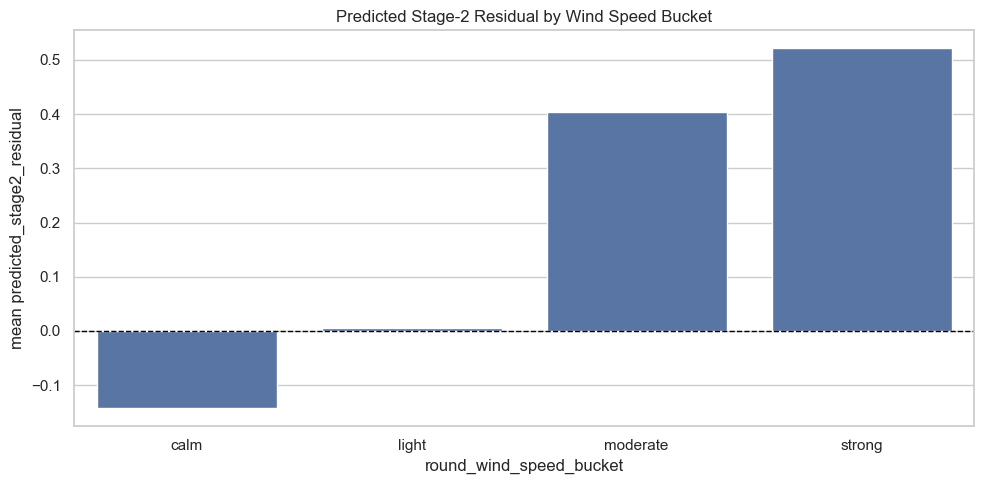

In [24]:
# -----------------------------------------------------------------------------
# Chart: stage-2 residual by wind speed bucket
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=two_stage_by_speed_bucket,
    x="round_wind_speed_bucket",
    y="predicted_stage2_residual_mean",
    order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Predicted Stage-2 Residual by Wind Speed Bucket")
plt.xlabel("round_wind_speed_bucket")
plt.ylabel("mean predicted_stage2_residual")
plt.tight_layout()
plt.show()


In [31]:
# -----------------------------------------------------------------------------
# Stage 1 feature importance
# -----------------------------------------------------------------------------

stage1_feature_importance_df = pd.DataFrame(
    {
        "feature": stage1_feature_cols,
        "importance": stage1_model.get_feature_importance(stage1_train_pool),
    }
).sort_values("importance", ascending=False).reset_index(drop=True)

stage1_feature_importance_df

,feature,importance
0,round_total_par,32.537183
1,player_rating,26.670428
2,round_length_over_par,8.646321
3,layout_id,6.956942
4,round_total_hole_length,6.772691
5,course_id,5.430524
6,hole_count,4.430356
7,round_avg_hole_par,3.256769
8,round_avg_hole_length,3.222028
9,division,1.239158


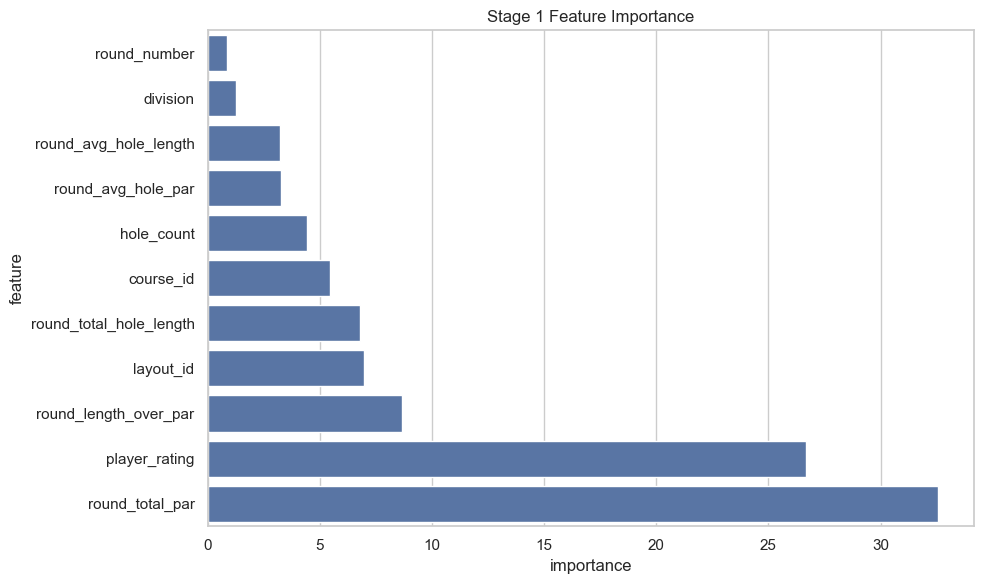

In [32]:
plt.figure(figsize=(10, 6))
plot_df = stage1_feature_importance_df.head(20).iloc[::-1]

sns.barplot(data=plot_df, x="importance", y="feature")
plt.title("Stage 1 Feature Importance")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()

In [33]:
# -----------------------------------------------------------------------------
# Stage 2 feature importance
# -----------------------------------------------------------------------------

stage2_feature_importance_df = pd.DataFrame(
    {
        "feature": stage2_feature_cols,
        "importance": stage2_model.get_feature_importance(stage2_train_pool),
    }
).sort_values("importance", ascending=False).reset_index(drop=True)

stage2_feature_importance_df

,feature,importance
0,round_temp_c_mean,21.628608
1,round_pressure_hpa_mean,20.575984
2,round_wind_speed_mps_mean,17.653665
3,round_humidity_pct_mean,16.205501
4,round_wind_gust_mps_mean,15.087194
5,round_precip_mm_sum,3.121040
6,round_wind_speed_mps_max,1.536435
7,round_wind_gust_mps_max,1.432110
8,round_wind_gust_bucket,1.249428
9,round_precip_mm_mean,0.760467


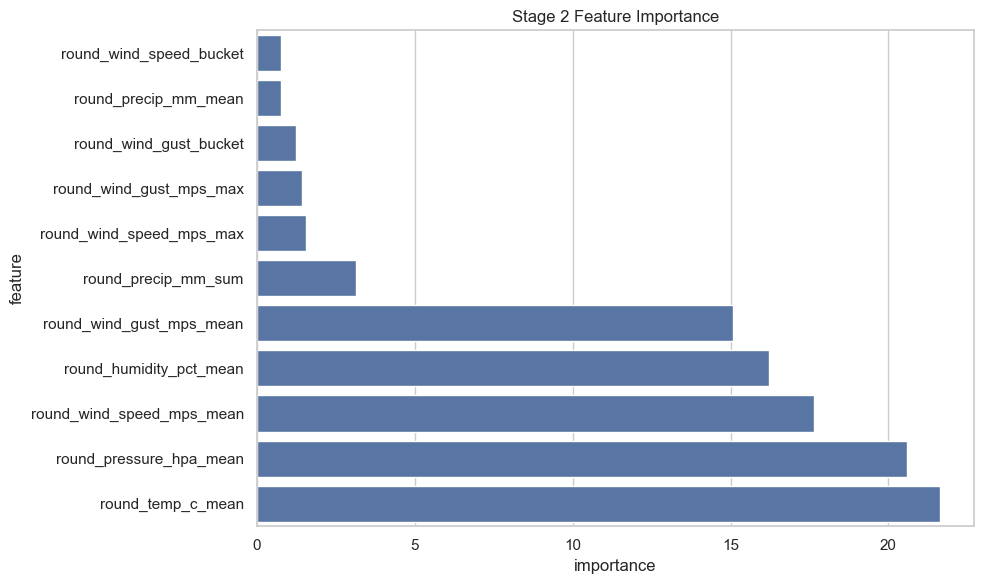

In [34]:
plt.figure(figsize=(10, 6))
plot_df = stage2_feature_importance_df.head(20).iloc[::-1]

sns.barplot(data=plot_df, x="importance", y="feature")
plt.title("Stage 2 Feature Importance")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
plt.show()